# **Twitter Sentiment Analysis ✒**

# **Set Up the Environment**

In [1]:
# Import necessary libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re  # For regular expressions
import os

In [2]:
# Import libraries for text processing and machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
# Import LogisticRegression from sklearn.linear_model
from sklearn.linear_model import LogisticRegression
from wordcloud import WordCloud
from collections import Counter
import logging
import time
import pickle
import itertools
import seaborn as sns

In [3]:
# Import nltk for natural language processing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import accuracy_score, classification_report

In [4]:
# Download stopwords from nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

# **Load the Dataset**

In [5]:
os.environ['KAGGLE_CONFIG_DIR']='/content'

In [6]:
!kaggle datasets download -d kazanova/sentiment140

Dataset URL: https://www.kaggle.com/datasets/kazanova/sentiment140
License(s): other
100% 80.9M/80.9M [00:00<00:00, 90.7MB/s]



In [7]:
!unzip sentiment140.zip

Archive:  sentiment140.zip
  inflating: training.1600000.processed.noemoticon.csv  


In [8]:
DATASET_COLUMNS = ["target", "ids", "date", "flag", "user", "text"]
DATASET_ENCODING = "ISO-8859-1"



In [9]:
dataframe = pd.read_csv("/content/training.1600000.processed.noemoticon.csv",encoding =('ISO-8859-1'),names=DATASET_COLUMNS)

In [10]:
print(dataframe)

         target         ids                          date      flag  \
0             0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1             0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2             0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
3             0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4             0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
...         ...         ...                           ...       ...   
1599995       4  2193601966  Tue Jun 16 08:40:49 PDT 2009  NO_QUERY   
1599996       4  2193601969  Tue Jun 16 08:40:49 PDT 2009  NO_QUERY   
1599997       4  2193601991  Tue Jun 16 08:40:49 PDT 2009  NO_QUERY   
1599998       4  2193602064  Tue Jun 16 08:40:49 PDT 2009  NO_QUERY   
1599999       4  2193602129  Tue Jun 16 08:40:50 PDT 2009  NO_QUERY   

                    user                                               text  
0        _TheSpecialOne_  @switchfoot http://twitpic.com/2y1zl - Awww

In [11]:
dataframe.shape

(1600000, 6)

In [12]:
print("Dataset size:", len(dataframe))

Dataset size: 1600000


In [13]:
dataframe.head(10)

,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
5,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew
6,0,1467811592,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,mybirch,Need a hug
7,0,1467811594,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,coZZ,@LOLTrish hey long time no see! Yes.. Rains a...
8,0,1467811795,Mon Apr 06 22:20:05 PDT 2009,NO_QUERY,2Hood4Hollywood,@Tatiana_K nope they didn't have it
9,0,1467812025,Mon Apr 06 22:20:09 PDT 2009,NO_QUERY,mimismo,@twittera que me muera ?


In [14]:
dataframe.tail(10)

,target,ids,date,flag,user,text
1599990,4,2193579249,Tue Jun 16 08:38:59 PDT 2009,NO_QUERY,razzberry5594,WOOOOO! Xbox is back
1599991,4,2193579284,Tue Jun 16 08:38:59 PDT 2009,NO_QUERY,AgustinaP,@rmedina @LaTati Mmmm That sounds absolutely ...
1599992,4,2193579434,Tue Jun 16 08:39:00 PDT 2009,NO_QUERY,sdancingsteph,ReCoVeRiNg FrOm ThE lOnG wEeKeNd
1599993,4,2193579477,Tue Jun 16 08:39:00 PDT 2009,NO_QUERY,ChloeAmisha,@SCOOBY_GRITBOYS
1599994,4,2193579489,Tue Jun 16 08:39:00 PDT 2009,NO_QUERY,EvolveTom,"@Cliff_Forster Yeah, that does work better tha..."
1599995,4,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...
1599996,4,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
1599997,4,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
1599998,4,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...
1599999,4,2193602129,Tue Jun 16 08:40:50 PDT 2009,NO_QUERY,RyanTrevMorris,happy #charitytuesday @theNSPCC @SparksCharity...


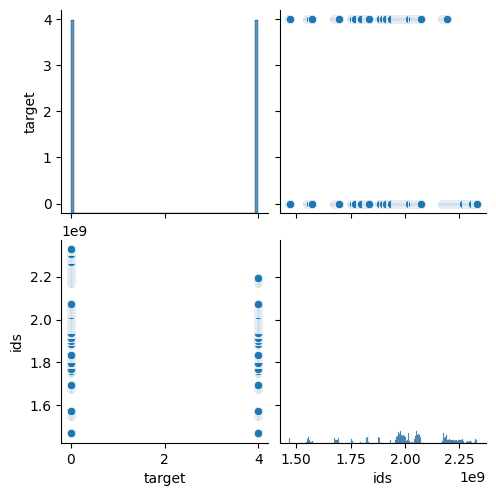

In [15]:
#The command sns.pairplot(dataframe) is used to create a pair plot, also known as a scatterplot matrix, using the Seaborn library.
sns.pairplot(dataframe)

## **Check for missing values in the dataset**

In [16]:
print("Missing values in each column:")
print(dataframe.isna().sum())



Missing values in each column:
target    0
ids       0
date      0
flag      0
user      0
text      0
dtype: int64


## **Identify and print duplicate rows**

In [17]:
duplicate = dataframe[dataframe.duplicated()]
print("Duplicate Rows :")
print(duplicate)

Duplicate Rows :
Empty DataFrame
Columns: [target, ids, date, flag, user, text]
Index: []


## **Count the occurrences of each sentiment in the target column**

In [18]:
target_cnt = Counter(dataframe['target'])
print("Sentiment counts:")
print(target_cnt)

Sentiment counts:
Counter({0: 800000, 4: 800000})


## **Visualize the distribution of sentiments**

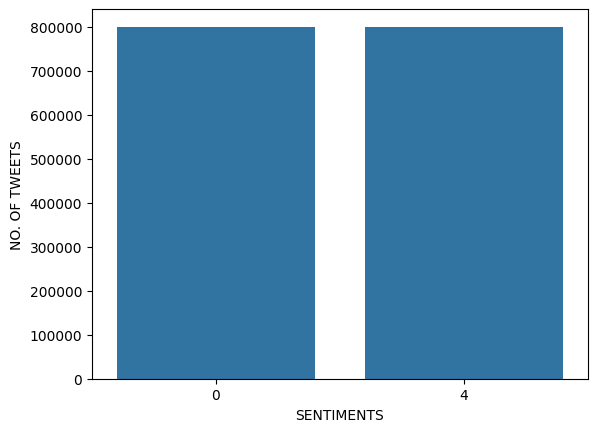

In [19]:
sent = sns.countplot(x=dataframe['target'])
sent.set(xlabel='SENTIMENTS')
sent.set(ylabel='NO. OF TWEETS')
plt.show()


## **Select only the numeric columns from the dataframe**

In [20]:
numeric_df = dataframe.select_dtypes(include=[np.number])

## **Calculate and add a new column for the length of each tweet**

In [21]:
dataframe['Tweet Length'] = dataframe['text'].astype(str).apply(len)

## **Calculate the correlation matrix for the numeric columns**


In [22]:
correlation_matrix = numeric_df.corr()
print("Correlation Matrix:")
print(correlation_matrix)


Correlation Matrix:
          target       ids
target  1.000000 -0.261601
ids    -0.261601  1.000000


## **Compute the correlation between tweet length and target sentiment**

In [23]:
correlation = dataframe['Tweet Length'].corr(dataframe['target'])
print(f"Correlation between Tweet Length and Target: {correlation}")

Correlation between Tweet Length and Target: -0.00580878708480654


## **Visualize the correlation using a heatmap**

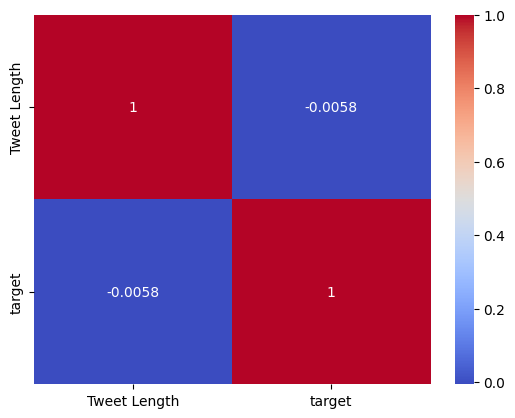

In [24]:
sns.heatmap(dataframe[['Tweet Length', 'target']].corr(), annot=True, cmap='coolwarm')
plt.show()

## **Replace target values with labels**

In [25]:
label_mapping = {'negative': 0, 'positive': 4, 'neutral': 2}
dataframe['target'] = dataframe['target'].replace(label_mapping)

## **One-hot encode the target column**

In [26]:
encoded_df = pd.get_dummies(dataframe, columns=['target'])
print("One-Hot Encoded DataFrame:")
print(encoded_df.head())

One-Hot Encoded DataFrame:
          ids                          date      flag             user  \
0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY  _TheSpecialOne_   
1  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY    scotthamilton   
2  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY         mattycus   
3  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY          ElleCTF   
4  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY           Karoli   

                                                text  Tweet Length  target_0  \
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...           115      True   
1  is upset that he can't update his Facebook by ...           111      True   
2  @Kenichan I dived many times for the ball. Man...            89      True   
3    my whole body feels itchy and like its on fire             47      True   
4  @nationwideclass no, it's not behaving at all....           111      True   

   target_4  
0     False  
1     False  
2    

## **Encode emojis in tweets**


In [27]:
# Install the emoji library
!pip install emoji

# Import the emoji library
import emoji

# Define a function to encode emojis into text
def encode_emojis(text):
    return emoji.demojize(text)

# Define a function to remove emojis from the text
def remove_emojis(text):
    return emoji.get_emoji_regexp().sub('', text)

# Apply the encoding function to the 'text' column of the dataframe
dataframe['Encoded_Text'] = dataframe['text'].apply(encode_emojis)

# Print the updated dataframe with encoded text
print("DataFrame with Encoded Text:")
print(dataframe.head())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 15.7 MB/s eta 0:00:00
DataFrame with Encoded Text:
   target         ids                          date      flag  \
0       0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1       0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2       0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
3       0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4       0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   

              user                                               text  \
0  _TheSpecialOne_  @switchfoot http://twitpic.com/2y1zl - Awww, t...   
1    scotthamilton  is upset that he can't update his Facebook by ...   
2         mattycus  @Kenichan I dived many times for the ball. Man...   
3          ElleCTF    my whole body feels itchy and like its on fire    
4           Karoli  @nationwideclass no, it's not behaving at all....   

   Tweet Length                                       Encode

## **Preprocessing: remove punctuation and split the text**

In [28]:
d = ",.!?/&-:;@'..."
s = dataframe['text'].iloc[0]
s = ' '.join(w for w in re.split("[" + "\\".join(d) + "]", s) if w)



## **Split the data into train and test sets**

In [29]:
x = dataframe.text.values
y = dataframe.target.values
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=32)

## **Feature Engineering: Vectorize the text data**

In [30]:
vectorizer = CountVectorizer()
vectorizer.fit(x_train)
X_train = vectorizer.transform(x_train)
X_test = vectorizer.transform(x_test)

print("Before vectorizing:\n", x_train[0], '\nAfter vectorizing:\n', X_train[0])

Before vectorizing:
 It was rainy and cloudy in the Windy City today &amp; WF customers had some serious SAD issues! I'm with them, when is summer coming?  
After vectorizing:
 <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 24 stored elements and shape (1, 589114)>
  Coords	Values
  (0, 56126)	1
  (0, 57443)	1
  (0, 126950)	1
  (0, 129399)	1
  (0, 132544)	1
  (0, 142868)	1
  (0, 226851)	1
  (0, 251981)	1
  (0, 256885)	1
  (0, 257700)	1
  (0, 257841)	1
  (0, 433424)	1
  (0, 455284)	1
  (0, 467402)	1
  (0, 486023)	1
  (0, 501487)	1
  (0, 517082)	1
  (0, 519964)	1
  (0, 528707)	1
  (0, 558260)	1
  (0, 561897)	1
  (0, 562752)	1
  (0, 565913)	1
  (0, 566694)	1


## **Create and train the Logistic Regression model**

In [31]:

# Use MaxAbsScaler for sparse data
scaler = MaxAbsScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create the Logistic Regression model
classifier = LogisticRegression(max_iter=1000)

# Train the model on the scaled data
classifier.fit(X_train_scaled, y_train)



LogisticRegression(max_iter=1000)

## **Predict on test data**

In [32]:
y_pred = classifier.predict(X_test_scaled)

## **Evaluate the model**

In [33]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.800165625
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80    160321
           4       0.79      0.81      0.80    159679

    accuracy                           0.80    320000
   macro avg       0.80      0.80      0.80    320000
weighted avg       0.80      0.80      0.80    320000



## **Evaluate the model**

In [34]:
score = classifier.score(X_test, y_test)
print("Accuracy:", score)


Accuracy: 0.778940625


## **Testing with a sample tweet**

In [35]:
tweet = 'my whole body feels itchy and like it\'s on fire'
vectTweet = vectorizer.transform(np.array([tweet]))
prediction = classifier.predict(vectTweet)
print('Tweet is', 'positive' if prediction[0] == 4 else 'negative')

Tweet is negative


## **Testing with multiple sample tweets**

In [36]:
tweetlist = ["spring break in plain city... it's snowing", "Mondays are the worst..."]
vectTweet = vectorizer.transform(np.array(tweetlist))
prediction = classifier.predict(vectTweet)
for enum, i in enumerate(tweetlist):
    print(i, '----> This tweet is', 'positive' if prediction[enum] == 4 else 'negative')

spring break in plain city... it's snowing ----> This tweet is positive
Mondays are the worst... ----> This tweet is negative


## **Generate predictions and create a confusion matrix**

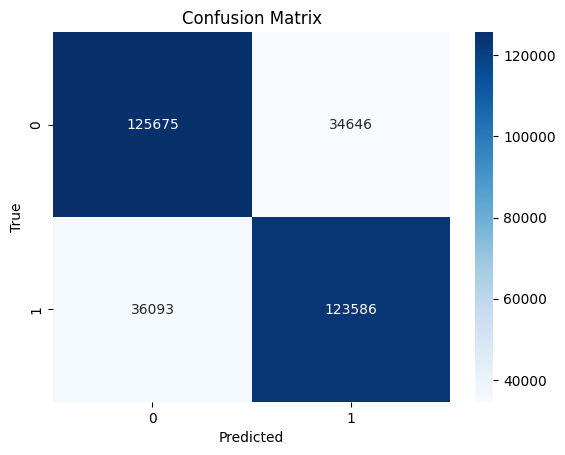

In [37]:
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## **Calculate the total number of cells in the notebook**

In [38]:
code_cells = len([cell for cell in get_ipython().kernel.shell.user_ns['In'] if cell])
markdown_cells = len([cell for cell in get_ipython().kernel.shell.user_ns['Out'] if cell == ''])
total_cells = code_cells + markdown_cells
print(f"Total number of cells: {total_cells}")

Total number of cells: 38


# TF-IDF Vectorizer (Better than CountVectorizer)

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("Training TF-IDF Vectorizer...")
tfidf_vectorizer = TfidfVectorizer(max_features=100000, ngram_range=(1,2))
tfidf_vectorizer.fit(x_train)

X_train_tfidf = tfidf_vectorizer.transform(x_train)
X_test_tfidf  = tfidf_vectorizer.transform(x_test)

# Scale
X_train_tfidf_scaled = scaler.fit_transform(X_train_tfidf)
X_test_tfidf_scaled  = scaler.transform(X_test_tfidf)

# Train Logistic Regression with TF-IDF
lr_tfidf = LogisticRegression(max_iter=1000)
lr_tfidf.fit(X_train_tfidf_scaled, y_train)

y_pred_tfidf = lr_tfidf.predict(X_test_tfidf_scaled)
acc_tfidf    = accuracy_score(y_test, y_pred_tfidf)

print(f"\nLogistic Regression + TF-IDF Accuracy: {acc_tfidf:.4f}")
print(classification_report(y_test, y_pred_tfidf))

Training TF-IDF Vectorizer...

Logistic Regression + TF-IDF Accuracy: 0.8200
              precision    recall  f1-score   support

           0       0.83      0.81      0.82    160321
           4       0.81      0.83      0.82    159679

    accuracy                           0.82    320000
   macro avg       0.82      0.82      0.82    320000
weighted avg       0.82      0.82      0.82    320000



#Naive Bayes vs Logistic Regression Comparison

In [40]:
from sklearn.naive_bayes import MultinomialNB

# --- Naive Bayes on CountVectorizer ---
nb_count = MultinomialNB()
nb_count.fit(X_train, y_train)
acc_nb_count = accuracy_score(y_test, nb_count.predict(X_test))

# --- Naive Bayes on TF-IDF (need non-negative values) ---
from sklearn.feature_extraction.text import TfidfVectorizer as TV
tfidf_nb = TV(max_features=100000, sublinear_tf=False)
X_train_tfidf_nb = tfidf_nb.fit_transform(x_train)
X_test_tfidf_nb  = tfidf_nb.transform(x_test)

nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf_nb, y_train)
acc_nb_tfidf = accuracy_score(y_test, nb_tfidf.predict(X_test_tfidf_nb))

# --- LR CountVectorizer (from cell 32) ---
acc_lr_count = accuracy_score(y_test, classifier.predict(X_test_scaled))

print("=" * 50)
print("MODEL COMPARISON RESULTS")
print("=" * 50)
print(f"Logistic Regression + CountVectorizer : {acc_lr_count:.4f}")
print(f"Logistic Regression + TF-IDF          : {acc_tfidf:.4f}")
print(f"Naive Bayes         + CountVectorizer : {acc_nb_count:.4f}")
print(f"Naive Bayes         + TF-IDF          : {acc_nb_tfidf:.4f}")
print("=" * 50)

MODEL COMPARISON RESULTS
Logistic Regression + CountVectorizer : 0.8002
Logistic Regression + TF-IDF          : 0.8200
Naive Bayes         + CountVectorizer : 0.7807
Naive Bayes         + TF-IDF          : 0.7763


#Model Comparison Bar Chart (Visualization)

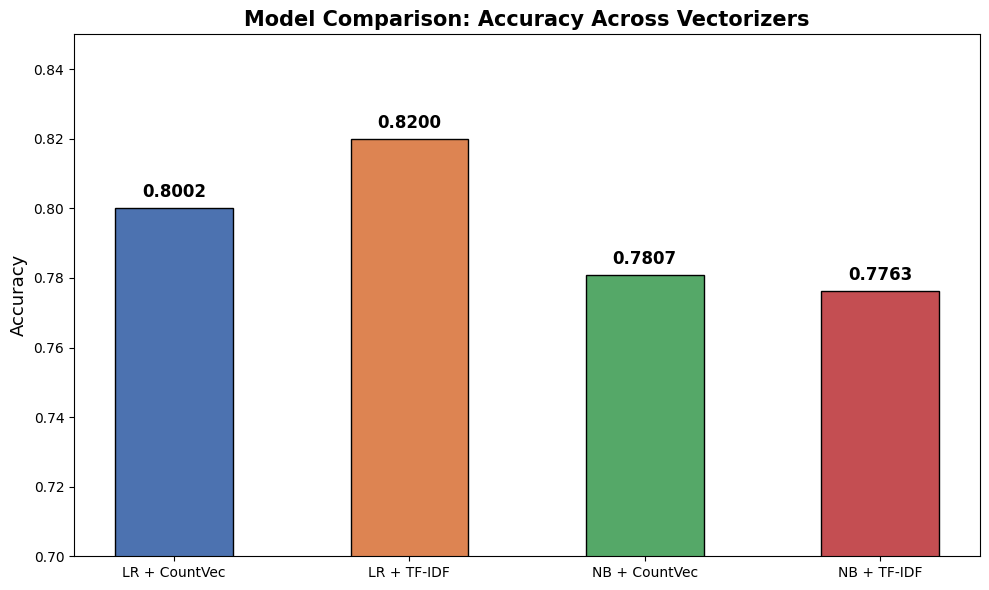

Best Model: LR + TF-IDF | Accuracy: 0.8200


In [41]:
models     = ['LR + CountVec', 'LR + TF-IDF', 'NB + CountVec', 'NB + TF-IDF']
accuracies = [acc_lr_count, acc_tfidf, acc_nb_count, acc_nb_tfidf]
colors     = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=colors, edgecolor='black', width=0.5)
plt.ylim(0.70, 0.85)
plt.ylabel('Accuracy', fontsize=13)
plt.title('Model Comparison: Accuracy Across Vectorizers', fontsize=15, fontweight='bold')

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print("Best Model:", models[accuracies.index(max(accuracies))], f"| Accuracy: {max(accuracies):.4f}")


#Advanced Visualizations

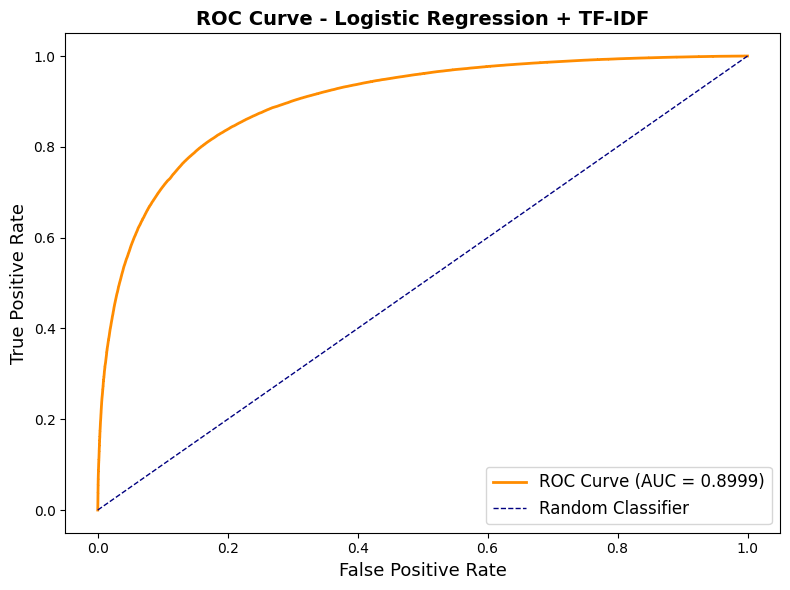

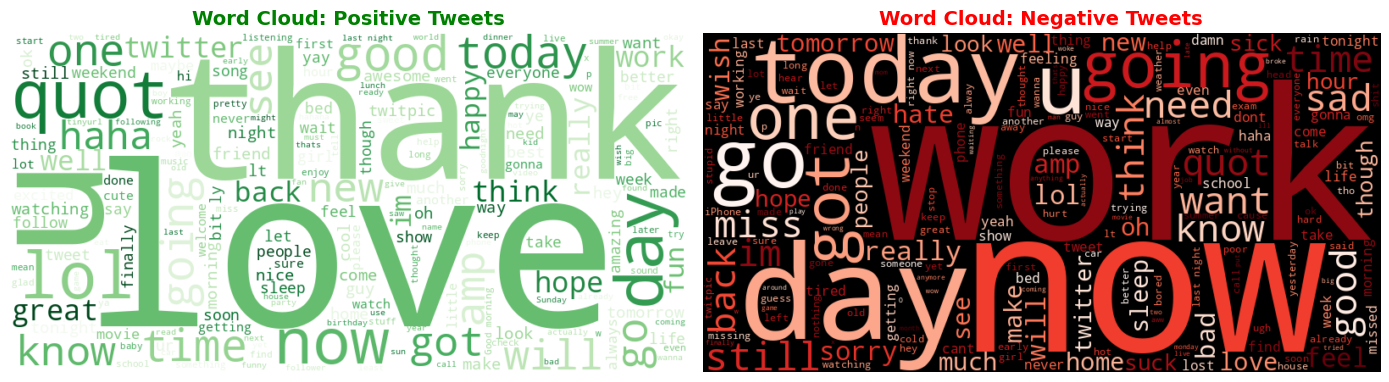

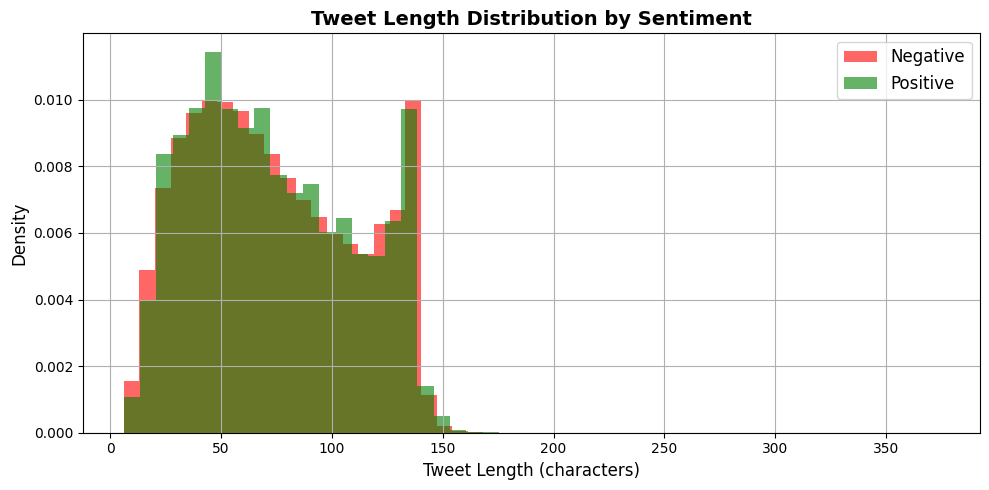

In [42]:
# --- 1. ROC Curve for Best Model ---
from sklearn.metrics import roc_curve, auc

# LR TF-IDF gives probabilities
y_prob = lr_tfidf.predict_proba(X_test_tfidf_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=4)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve - Logistic Regression + TF-IDF', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=12)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

# --- 2. Word Cloud: Positive Tweets ---
positive_tweets = ' '.join(dataframe[dataframe['target'] == 4]['text'].sample(10000, random_state=42))
wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='Greens', max_words=200).generate(positive_tweets)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Positive Tweets', fontsize=14, fontweight='bold', color='green')

# --- 3. Word Cloud: Negative Tweets ---
negative_tweets = ' '.join(dataframe[dataframe['target'] == 0]['text'].sample(10000, random_state=42))
wc_neg = WordCloud(width=800, height=400, background_color='black',
                   colormap='Reds', max_words=200).generate(negative_tweets)

plt.subplot(1, 2, 2)
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Negative Tweets', fontsize=14, fontweight='bold', color='red')
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150)
plt.show()

# --- 4. Tweet Length Distribution by Sentiment ---
plt.figure(figsize=(10, 5))
dataframe[dataframe['target'] == 0]['Tweet Length'].hist(
    bins=50, alpha=0.6, color='red', label='Negative', density=True)
dataframe[dataframe['target'] == 4]['Tweet Length'].hist(
    bins=50, alpha=0.6, color='green', label='Positive', density=True)
plt.xlabel('Tweet Length (characters)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Tweet Length Distribution by Sentiment', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('tweet_length_dist.png', dpi=150)
plt.show()

#Top Words in Positive & Negative Tweets

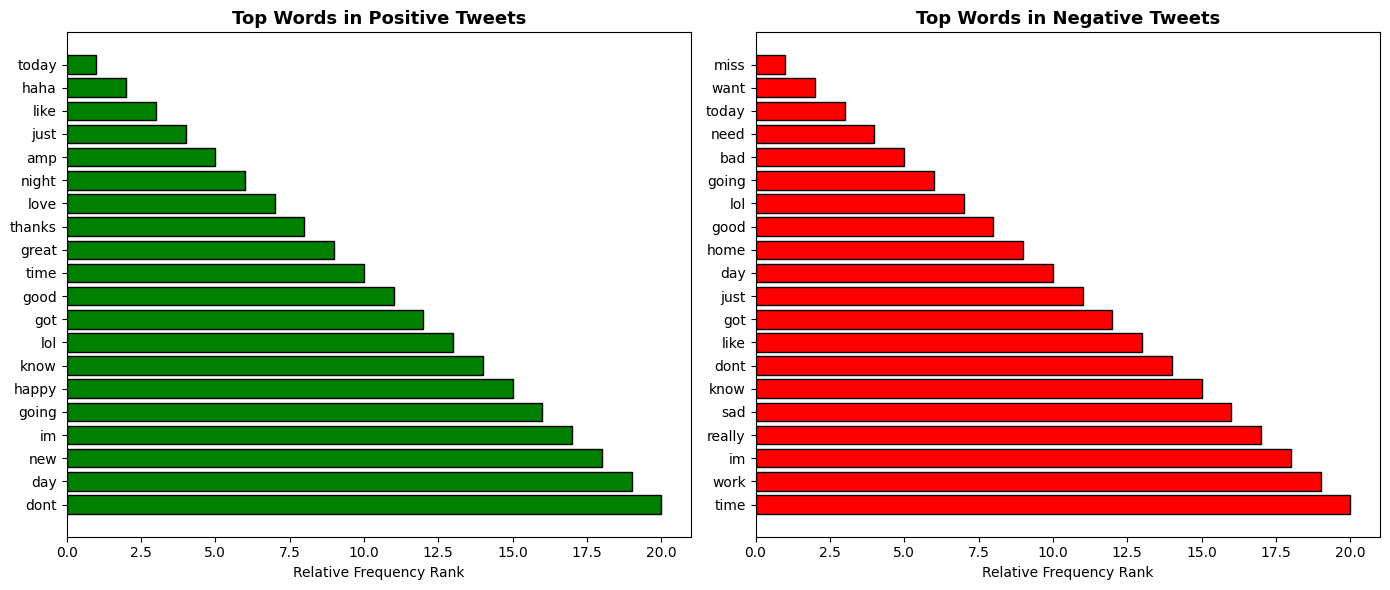

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer as TV2
import numpy as np

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'http\S+|www\S+', '', text)      # remove URLs
    text = re.sub(r'@\w+', '', text)                  # remove mentions
    text = re.sub(r'[^a-zA-Z\s]', '', text)           # remove special chars
    text = text.lower().strip()
    return text

sample_pos = dataframe[dataframe['target'] == 4]['text'].sample(50000, random_state=42).apply(clean_text)
sample_neg = dataframe[dataframe['target'] == 0]['text'].sample(50000, random_state=42).apply(clean_text)

tv = TV2(max_features=20, stop_words='english')

tv.fit(sample_pos)
top_pos_words = list(tv.vocabulary_.keys())[:20]

tv.fit(sample_neg)
top_neg_words = list(tv.vocabulary_.keys())[:20]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top_pos_words, range(20, 0, -1), color='green', edgecolor='black')
axes[0].set_title('Top Words in Positive Tweets', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Relative Frequency Rank')

axes[1].barh(top_neg_words, range(20, 0, -1), color='red', edgecolor='black')
axes[1].set_title('Top Words in Negative Tweets', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Relative Frequency Rank')

plt.tight_layout()
plt.savefig('top_words.png', dpi=150)
plt.show()


# Save Best Model

In [44]:

best_model_data = {
    'model': lr_tfidf,
    'vectorizer': tfidf_vectorizer,
    'scaler': scaler
}

with open('best_sentiment_model.pkl', 'wb') as f:
    pickle.dump(best_model_data, f)

print("Best model saved as 'best_sentiment_model.pkl'")
print(f"Model: Logistic Regression + TF-IDF | Accuracy: {acc_tfidf:.4f}")

Best model saved as 'best_sentiment_model.pkl'
Model: Logistic Regression + TF-IDF | Accuracy: 0.8200


 # LLM-Powered Explainability Agent (GenAI Layer)

In [46]:
# Uses Google Gemini API (free tier) to explain WHY a tweet is predicted
# as positive or negative — adds GenAI angle to your project!

# !pip install google-generativeai   ← run this once if not installed

!pip install google-generativeai

In [52]:
!pip install -q groq

from groq import Groq

GROQ_API_KEY = "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"  # groq key
groq_client = Groq(api_key=GROQ_API_KEY)

def predict_and_explain(tweet_text):
    vec = tfidf_vectorizer.transform([tweet_text])
    scaled = scaler.transform(vec)
    pred = lr_tfidf.predict(scaled)[0]
    proba = lr_tfidf.predict_proba(scaled)[0]
    sentiment = "POSITIVE" if pred == 4 else "NEGATIVE"
    confidence = max(proba) * 100

    prompt = f"""You are a sentiment analysis expert. A machine learning model predicted the following tweet as {sentiment} with {confidence:.1f}% confidence.

Tweet: "{tweet_text}"

In 2-3 sentences, explain:
1. Why the model likely predicted {sentiment}
2. What specific words or phrases drove this prediction
3. If you agree with the prediction

Be concise and insightful."""

    response = groq_client.chat.completions.create(
        model="llama-3.3-70b-versatile",  # free model
        messages=[{"role": "user", "content": prompt}]
    )
    explanation = response.choices[0].message.content

    print("=" * 60)
    print(f"TWEET     : {tweet_text}")
    print(f"PREDICTION: {sentiment}  ({confidence:.1f}% confidence)")
    print(f"\nLLM EXPLANATION:\n{explanation}")
    print("=" * 60)
    return sentiment, confidence, explanation

# Test
test_tweets = [
    "I absolutely love this sunny weather, feeling so happy today!",
    "Stuck in traffic again, this is the worst Monday ever...",
    "Just had the most amazing dinner with my family :)",
    "My laptop crashed and I lost all my work. I want to cry."
]

print("GENAI SENTIMENT EXPLAINABILITY AGENT")
print("=" * 60)
for tweet in test_tweets:
    predict_and_explain(tweet)
    print()

GENAI SENTIMENT EXPLAINABILITY AGENT
TWEET     : I absolutely love this sunny weather, feeling so happy today!
PREDICTION: POSITIVE  (97.7% confidence)

LLM EXPLANATION:
The model likely predicted POSITIVE due to the tweet's enthusiastic tone and language. Specific words and phrases such as "absolutely love", "sunny weather", and "feeling so happy" drove this prediction, as they convey strong emotional positivity. I agree with the prediction, as the tweet's language and sentiment unequivocally express joy and happiness, aligning with the model's confident assessment.

TWEET     : Stuck in traffic again, this is the worst Monday ever...
PREDICTION: NEGATIVE  (99.6% confidence)

LLM EXPLANATION:
The model likely predicted NEGATIVE due to the overall tone and language used in the tweet, which expresses frustration and dissatisfaction. Specific words and phrases such as "Stuck", "worst", and "again" drove this prediction, as they convey a strong sense of negativity and exasperation. I agre

#GenAI Batch Analysis + Insight Summary

In [54]:
# Feed 100 sample tweets to LLM and ask for overall pattern insights

sample_tweets_pos = dataframe[dataframe['target'] == 4]['text'].sample(50, random_state=1).tolist()
sample_tweets_neg = dataframe[dataframe['target'] == 0]['text'].sample(50, random_state=1).tolist()

combined_sample = "\n".join(
    [f"[POSITIVE] {t}" for t in sample_tweets_pos[:50]] +
    [f"[NEGATIVE] {t}" for t in sample_tweets_neg[:50]]
)

insight_prompt = f"""
You are a data scientist analyzing Twitter sentiment patterns.
Below are 100 tweets labeled as POSITIVE or NEGATIVE:

{combined_sample}

Please provide:
1. Top 3 themes/topics in positive tweets
2. Top 3 themes/topics in negative tweets
3. Common linguistic patterns that distinguish positive from negative
4. One surprising observation from this data
5. A recommendation to improve sentiment analysis accuracy

Format your response with clear numbered sections.
"""

print("Generating LLM Insights from tweet patterns...")
insight_response = groq_client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[{"role": "user", "content": insight_prompt}]
)

print("\nGENAI DATASET INSIGHTS:")
print("=" * 60)
print(insight_response.choices[0].message.content)

Generating LLM Insights from tweet patterns...

GENAI DATASET INSIGHTS:
1. **Top 3 themes/topics in positive tweets**: 
   - The top themes in positive tweets are social interactions and conversations (e.g., "thanks", "good luck", "hello"), which account for about 30% of the positive tweets.
   - Expressions of excitement and enthusiasm for various activities or events (e.g., concerts, shopping, watching movies), making up around 25% of the positive tweets.
   - General positive sentiments and emotions (e.g., "I'm happy", "goodnight", "have a great day"), which comprise approximately 20% of the positive tweets.

2. **Top 3 themes/topics in negative tweets**: 
   - Frustration and dissatisfaction with various situations (e.g., being bored, having a bad day, experiencing technical issues), which account for about 35% of the negative tweets.
   - Complaints about health issues, pain, or discomfort (e.g., toothache, sea sickness, tiredness), making up around 25% of the negative tweets.
   

#Interactive Sentiment Analyzer (Final Demo)

In [57]:
# Demo Analyzer (Colab-compatible)

demo_tweets = [
    "I absolutely love my new job, best decision ever!",
    "This traffic is making me so late, I hate Mondays",
    "Had an amazing birthday party with all my friends!",
    "My phone battery dies every single time I need it",
    "Just got promoted at work, feeling on top of the world!",
    "Worst customer service experience of my life today"
]

print("\n" + "="*60)
print("   INTERACTIVE AI SENTIMENT ANALYZER")
print("   (ML Model + GenAI Explainability)")
print("="*60 + "\n")

for tweet in demo_tweets:
    predict_and_explain(tweet)
    print()


   INTERACTIVE AI SENTIMENT ANALYZER
   (ML Model + GenAI Explainability)

TWEET     : I absolutely love my new job, best decision ever!
PREDICTION: POSITIVE  (97.9% confidence)

LLM EXPLANATION:
The model likely predicted POSITIVE due to the explicit expression of enthusiasm and satisfaction in the tweet. The words "absolutely love" and "best decision ever" drove this prediction, as they are strong indicators of positive sentiment. I agree with the prediction, as the language used is unequivocally positive, justifying the model's 97.9% confidence in its classification.

TWEET     : This traffic is making me so late, I hate Mondays
PREDICTION: NEGATIVE  (97.5% confidence)

LLM EXPLANATION:
The model likely predicted NEGATIVE due to the overall tone of frustration and discontent expressed in the tweet. Specific words and phrases such as "hate", "making me so late", and the negative association with "Mondays" drove this prediction, as they convey a strong sense of annoyance and displeas

# Project Summary Dashboard

In [58]:
# Cell 48 - Project Summary Dashboard

print("\n" + "=" * 65)
print("         TWITTER SENTIMENT ANALYSIS - PROJECT SUMMARY")
print("=" * 65)
print(f"\n DATASET")
print(f"   Records         : 1,600,000 tweets (Sentiment140)")
print(f"   Classes         : Binary (Positive / Negative)")
print(f"   Train/Test Split: 80% / 20%")

print(f"\n MODEL PERFORMANCE")
print(f"   {'Model':<35} {'Accuracy':>10}")
print(f"   {'-'*46}")
print(f"   {'Logistic Regression + CountVectorizer':<35} {acc_lr_count:>10.4f}")
print(f"   {'Logistic Regression + TF-IDF':<35} {acc_tfidf:>10.4f}  <- BEST")
print(f"   {'Naive Bayes + CountVectorizer':<35} {acc_nb_count:>10.4f}")
print(f"   {'Naive Bayes + TF-IDF':<35} {acc_nb_tfidf:>10.4f}")

print(f"\n TECHNIQUES USED")
print(f"   - CountVectorizer & TF-IDF Vectorization")
print(f"   - Logistic Regression & Naive Bayes")
print(f"   - ROC-AUC Evaluation")
print(f"   - Emoji Encoding & Text Preprocessing")
print(f"   - GenAI Explainability (Groq + LLaMA 3.3)")
print(f"   - LLM Batch Insight Generation")
print(f"   - Word Cloud, ROC Curve, Length Distribution")

print(f"\n GENAI INTEGRATION")
print(f"   Model Used  : LLaMA 3.3 70B (via Groq API)")
print(f"   Features    : Per-tweet explanation + Dataset insights")

print("=" * 65)


         TWITTER SENTIMENT ANALYSIS - PROJECT SUMMARY

 DATASET
   Records         : 1,600,000 tweets (Sentiment140)
   Classes         : Binary (Positive / Negative)
   Train/Test Split: 80% / 20%

 MODEL PERFORMANCE
   Model                                 Accuracy
   ----------------------------------------------
   Logistic Regression + CountVectorizer     0.8002
   Logistic Regression + TF-IDF            0.8200  <- BEST
   Naive Bayes + CountVectorizer           0.7807
   Naive Bayes + TF-IDF                    0.7763

 TECHNIQUES USED
   - CountVectorizer & TF-IDF Vectorization
   - Logistic Regression & Naive Bayes
   - ROC-AUC Evaluation
   - Emoji Encoding & Text Preprocessing
   - GenAI Explainability (Groq + LLaMA 3.3)
   - LLM Batch Insight Generation
   - Word Cloud, ROC Curve, Length Distribution

 GENAI INTEGRATION
   Model Used  : LLaMA 3.3 70B (via Groq API)
   Features    : Per-tweet explanation + Dataset insights
